In [13]:
%matplotlib widget
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

data = pd.read_csv("GPRMUltiInput.csv")

X = data[["Pressure_MPa", "Current_Density_mA_cm2"]]
y = data["Capacity_Retention_percent"] 

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

the data must be scaled otherwise pressure will be counted for less. all the regresser does basically is sqrt( (x-x1)^2 + (x-x2)^2) and if pressure is just like 5 or 6 but temperature is in the tens eg 10 and 90 then the contribution from temperature will completely outweigh the pressure even if pressure is more important.


In [14]:
kernel = (
    1.0 * RBF(length_scale=[1.0, 1.0])
    + WhiteKernel()
)

gpr = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=9
)

gpr.fit(X_scaled, y)

print(gpr.kernel_)


54.9**2 * RBF(length_scale=[0.879, 3.28]) + WhiteKernel(noise_level=1.43)


creating a kernel and then using gpr to optimise its hyperparameters (gpr.fit, gpr= is just set up variable)

/Users/emilechhowalla/Downloads/Internship Zhejiang/AI Project/Coding/scientific-env/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


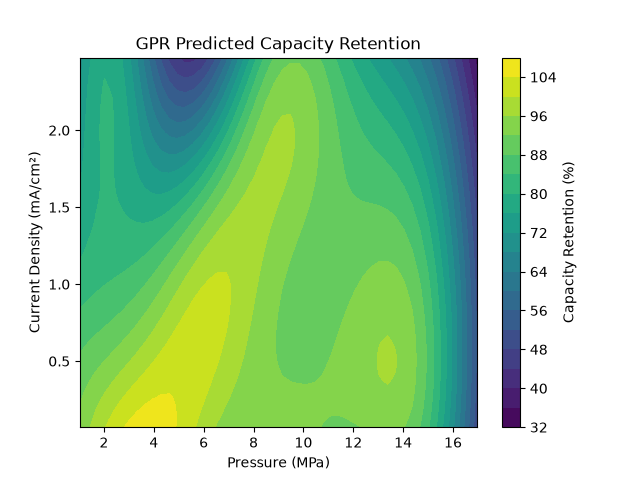

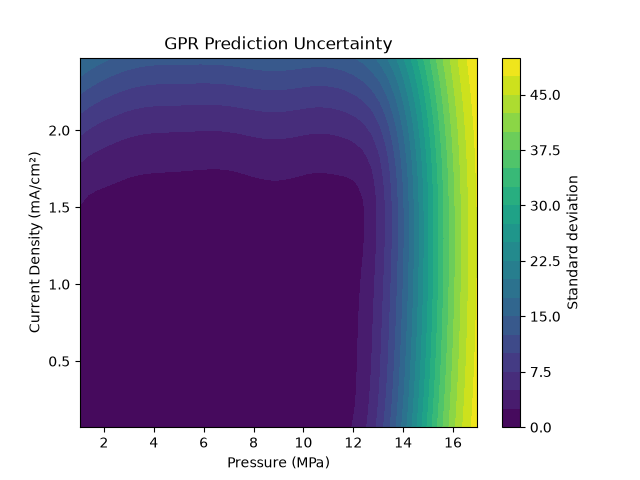

In [15]:
pressure = np.linspace(
    data["Pressure_MPa"].min(),
    data["Pressure_MPa"].max()+5,
    50
)

current_density = np.linspace(
    data["Current_Density_mA_cm2"].min(),
    data["Current_Density_mA_cm2"].max()+1.0,
    50
)

P, CD = np.meshgrid(pressure, current_density)


# Convert grid into input rows
X_grid = np.column_stack([
    P.ravel(),
    CD.ravel()
])


# Scale grid
X_grid_scaled = scaler.transform(X_grid)


# Predict
mean, std = gpr.predict(
    X_grid_scaled,
    return_std=True
)


# Put predictions back into grid shape
mean = mean.reshape(P.shape)
std = std.reshape(P.shape)


# Plot predicted surface as contour map
plt.figure()

plt.contourf(
    P,
    CD,
    mean,
    levels=20
)

plt.xlabel("Pressure (MPa)")
plt.ylabel("Current Density (mA/cm²)")
plt.title("GPR Predicted Capacity Retention")

plt.colorbar(label="Capacity Retention (%)")

plt.show()


# Plot uncertainty
plt.figure()

plt.contourf(
    P,
    CD,
    std,
    levels=20
)

plt.xlabel("Pressure (MPa)")
plt.ylabel("Current Density (mA/cm²)")
plt.title("GPR Prediction Uncertainty")

plt.colorbar(label="Standard deviation")

plt.show()

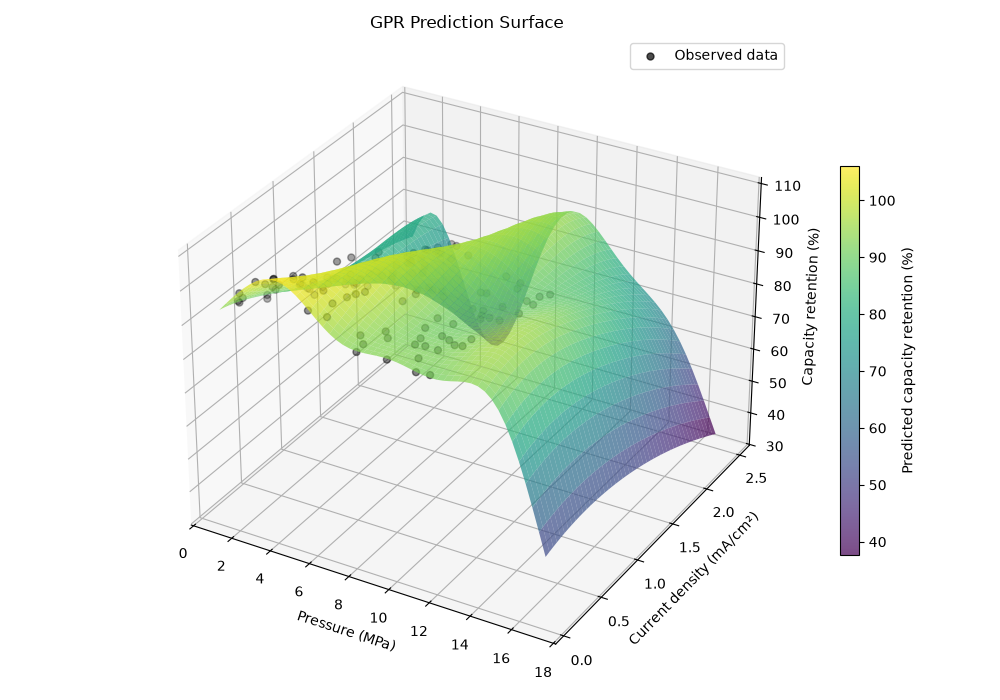

In [16]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

# GPR prediction surface
surface = ax.plot_surface(
    P,
    CD,
    mean,
    cmap="viridis",
    alpha=0.7,
    edgecolor="none"
 )

# Actual measurements
ax.scatter(
    data["Pressure_MPa"],
    data["Current_Density_mA_cm2"],
    data["Capacity_Retention_percent"],
    color="black",
    s=25,
    alpha=0.7,
    label="Observed data"
 )

ax.set_xlabel("Pressure (MPa)")
ax.set_ylabel("Current density (mA/cm²)")
ax.set_zlabel("Capacity retention (%)")
ax.set_title("GPR Prediction Surface")

fig.colorbar(surface, ax=ax, shrink=0.6, label="Predicted capacity retention (%)")
ax.legend()
plt.tight_layout()
plt.show()